# 04 — Competitive Market Structure
### Branch 3 of the MECE issue tree: the share-erosion story

**Hypotheses under test**

| ID | Hypothesis |
|---|---|
| H3.1 | Instamart is losing share of incremental category growth, not just slowing in absolute terms |
| H3.2 | Metro saturation caps achievable orders/store and AOV via demand-splitting across players |
| H3.3 | New entrants (Amazon Now, Flipkart Minutes) are fragmenting demand further |
| H3.4 | Zepto's higher throughput despite lower AOV proves frequency beats ticket size as a growth lever |

This is the branch with the richest, most chartable public data — order share, dark-store
footprints, and a clean two-variable strategic map — so it carries the most visual weight
in the case study, by design.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

candidates = [Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\processed"), Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\preprocessed")]
PROCESSED = next((p for p in candidates if p.exists()), candidates[0])
print(f"Using data directory: {PROCESSED.resolve()}")

master = pd.read_csv(PROCESSED / "master_metrics.csv")
print(f"Loaded {len(master)} rows from master_metrics.csv")


Using data directory: D:\Downloads\swiggy-instamart-casestudy\data\processed
Loaded 99 rows from master_metrics.csv


## Supplementary metrics for this branch

The master file now carries all three players' Jan 2026 market-share snapshot (Blinkit, Instamart,
Zepto). What it doesn't yet include as structured rows are the **new-entrant** figures (Flipkart
Minutes, Amazon Now, JioMart) needed for H3.3 — those came from the competitive-landscape research
rather than a structured data pull, so they're added here as a small branch-specific supplementary
table with clear sourcing. Zepto's dark-store count isn't disclosed anywhere — it's derived below from
disclosed order volume and the (already analyst-estimated) density figure, with the arithmetic shown
rather than just asserted.


In [2]:
# Instamart's Jan-2026 market share (24%) now lives in master_metrics.csv (row 86), so it is NOT
# re-added here — doing so would double-count it in the donut. This table holds only the new-entrant
# figures (Flipkart Minutes, Amazon Now, JioMart) that the master file doesn't carry as structured rows.
supplementary_rows = [
    dict(company="Flipkart Minutes", segment="Quick Commerce", period="Q1CY26", period_type="snapshot",
         metric="Dark Stores (count)", value=800, unit="count", confidence="analyst_estimate", source_id="S34",
         notes="Newer entrant, actively ramping — not a mature/stable network like the top 3"),
    dict(company="Flipkart Minutes", segment="Quick Commerce", period="current", period_type="snapshot",
         metric="Net Dark Store Adds per Month", value=100, unit="count", confidence="analyst_estimate", source_id="S34"),
    dict(company="Flipkart Minutes", segment="Quick Commerce", period="end2026_target", period_type="target",
         metric="Dark Stores (count)", value=1350, unit="count", confidence="analyst_estimate", source_id="S34",
         notes="Stated target band 1,200-1,500 stores by end-2026 (midpoint shown); a forward plan, not a current count"),

    dict(company="Amazon Now", segment="Quick Commerce", period="stated_target", period_type="target",
         metric="Micro-Fulfilment Centres (count)", value=1000, unit="count", confidence="disclosed", source_id="S34",
         notes="Stated as 'more than 1,000' (from ~300), Rs 2,800cr investment — a forward plan, NOT a current operating count"),
    dict(company="Amazon Now", segment="Quick Commerce", period="stated_target", period_type="target",
         metric="Cities Covered", value=100, unit="count", confidence="disclosed", source_id="S34"),

    dict(company="JioMart", segment="Quick Commerce", period="Q3FY26", period_type="quarterly",
         metric="Dark Stores (count)", value=800, unit="count", confidence="analyst_estimate", source_id="S35",
         notes="Reliance-backed entrant; ~1.6M orders/day (+53% QoQ), CFO claims contribution-margin positive on grocery-sourcing scale"),
]

supplementary = pd.DataFrame(supplementary_rows)
supplementary.to_csv(PROCESSED / "b3_supplementary_metrics.csv", index=False)
print(f"Supplementary table written — {len(supplementary)} rows")
supplementary

Supplementary table written — 6 rows


,company,segment,period,period_type,metric,value,unit,confidence,source_id,notes
0,Flipkart Minutes,Quick Commerce,Q1CY26,snapshot,Dark Stores (count),800,count,analyst_estimate,S34,"Newer entrant, actively ramping — not a mature/stable network like the top 3"
1,Flipkart Minutes,Quick Commerce,current,snapshot,Net Dark Store Adds per Month,100,count,analyst_estimate,S34,NaN
2,Flipkart Minutes,Quick Commerce,end2026_target,target,Dark Stores (count),1350,count,analyst_estimate,S34,"Stated target band 1,200-1,500 stores by end-2026 (midpoint shown); a forward plan, no..."
3,Amazon Now,Quick Commerce,stated_target,target,Micro-Fulfilment Centres (count),1000,count,disclosed,S34,"Stated as 'more than 1,000' (from ~300), Rs 2,800cr investment — a forward plan, NOT a..."
4,Amazon Now,Quick Commerce,stated_target,target,Cities Covered,100,count,disclosed,S34,NaN
5,JioMart,Quick Commerce,Q3FY26,quarterly,Dark Stores (count),800,count,analyst_estimate,S35,"Reliance-backed entrant; ~1.6M orders/day (+53% QoQ), CFO claims contribution-margin p..."


In [3]:

combined = pd.concat([master, supplementary], ignore_index=True)


## H3.1 — Order-share erosion, FY24 → FY26

The headline chart of this whole case study. Instamart's share of the top-3 players'
combined orders has fallen by more than a third in two years.


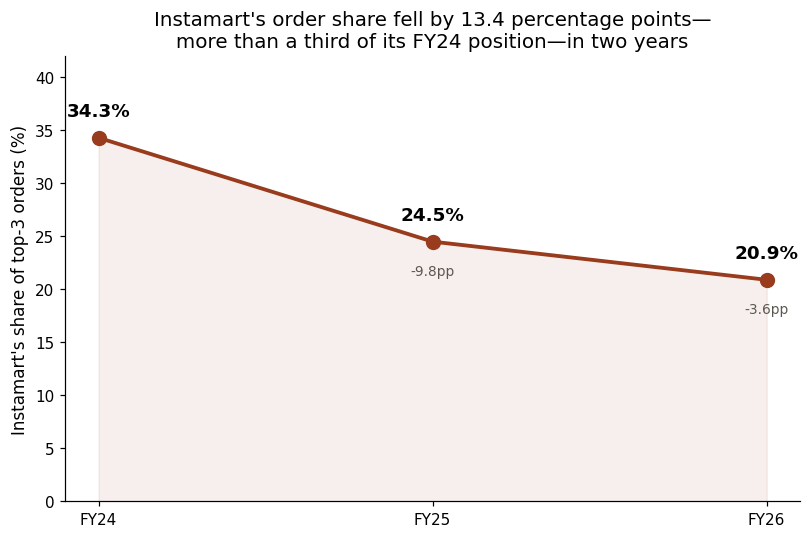

In [4]:

share = combined[combined.metric == "Instamart Order Share (of Top 3)"].copy()
share["period"] = pd.Categorical(share["period"], categories=["FY24", "FY25", "FY26"], ordered=True)
share = share.sort_values("period")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(share["period"].astype(str), share["value"], marker="o", markersize=9, color="#993C1D", linewidth=2.5)
ax.fill_between(range(len(share)), share["value"], color="#993C1D", alpha=0.08)

for i, (x, y) in enumerate(zip(share["period"].astype(str), share["value"])):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 14), ha="center",
                fontsize=12, fontweight="bold")
    if i > 0:
        prev_y = share["value"].iloc[i-1]
        pp_change = y - prev_y
        ax.annotate(f"{pp_change:+.1f}pp", (x, y), textcoords="offset points", xytext=(0, -22),
                    ha="center", fontsize=9, color="#5C5850")

ax.set_ylabel("Instamart's share of top-3 orders (%)", fontsize=11)
ax.set_ylim(0, 42)
ax.set_title("Instamart's order share fell by 13.4 percentage points\u2014\nmore than a third of its FY24 position\u2014in two years", fontsize=13)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(PROCESSED / "b3_chart_order_share_evolution.png", bbox_inches="tight")
plt.show()


**Verdict on H3.1:** Strongly supported and disclosed directly (via Zepto's UDRHP).
One caveat worth keeping in the deck's fine print: Zepto's IPO filings have an incentive
to frame competitor weakness favorably, so this series should ideally be cross-checked
against an independent source if one becomes available before the figures go into a
final presentation.


## The current snapshot: where that erosion has landed the market, Jan 2026

The order-share series above tracks *relative* position among the top 3 only. This
snapshot (a different methodology — Datum Intelligence's total-market estimate, not
UDRHP's top-3-only framing) shows where things stood as of January 2026, including the
smaller players the top-3 framing leaves out.

**Source caveat (keep in the deck's fine print):** no player publishes audited market share, so
these are analyst estimates and they **diverge materially** — Datum Intelligence/Reuters puts
Blinkit at ~46%, but BofA Research has pegged it **above 50%**, while Zepto's own UDRHP claims
~29% share for itself (vs the ~22% here). Treat the 46/24/22 split as one credible secondary
estimate, not a settled fact; the *direction* (Blinkit leads, Instamart second and slipping) is
robust across sources even where the levels are not.


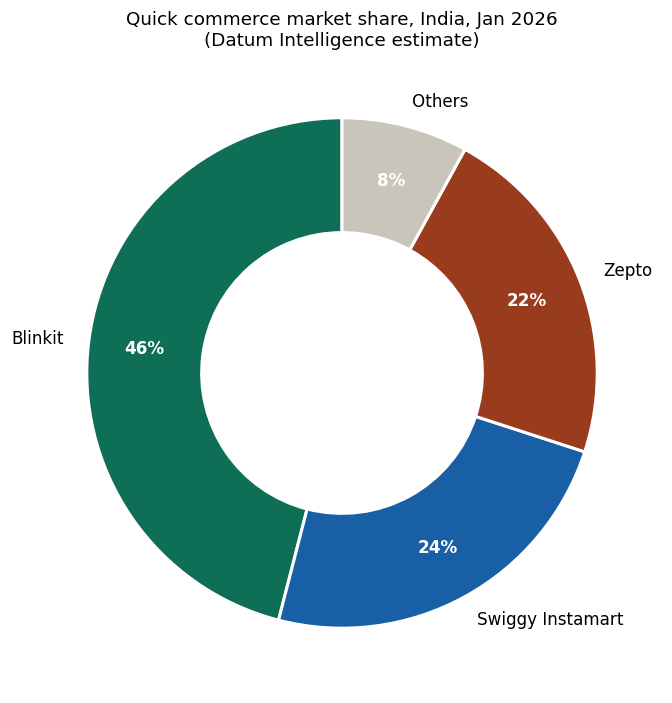

In [5]:

snapshot = combined[(combined.metric == "Market Share") & (combined.period == "Jan2026")].copy()
others_share = 100 - snapshot["value"].sum()
snapshot_full = pd.concat([
    snapshot[["company", "value"]],
    pd.DataFrame([{"company": "Others", "value": others_share}])
], ignore_index=True).sort_values("value", ascending=False)

colors = {"Blinkit": "#0F6E56", "Swiggy Instamart": "#185FA5", "Zepto": "#993C1D", "Others": "#C9C5BA"}
fig, ax = plt.subplots(figsize=(6.5, 6.5))
wedges, texts, autotexts = ax.pie(
    snapshot_full["value"], labels=snapshot_full["company"],
    autopct="%1.0f%%", startangle=90, pctdistance=0.78,
    colors=[colors[c] for c in snapshot_full["company"]],
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
ax.set_title("Quick commerce market share, India, Jan 2026\n(Datum Intelligence estimate)", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / "b3_chart_market_share_donut.png", bbox_inches="tight")
plt.show()


## H3.3 — New entrants are adding to an already-crowded field

First, the only honest way to put Zepto on this chart: its dark-store count isn't
disclosed anywhere, so it has to be derived from two numbers that *are* disclosed/estimated
— Q4 FY26 order volume and the (already analyst-estimated) density figure. The arithmetic
is shown below rather than just asserted, so the assumption is visible and checkable.


In [6]:

zepto_orders_q4fy26 = combined.loc[(combined.company == "Zepto") & (combined.metric == "Orders"), "value"].iloc[0] * 1_000_000
zepto_density = combined.loc[(combined.company == "Zepto") & (combined.metric == "Orders per Store per Day"), "value"].iloc[0]
DAYS_IN_Q4_FY26 = 90  # Jan-Mar 2026: 31 + 28 + 31, not a leap year

zepto_orders_per_day = zepto_orders_q4fy26 / DAYS_IN_Q4_FY26
zepto_implied_stores = zepto_orders_per_day / zepto_density

print(f"Zepto Q4 FY26 orders: {zepto_orders_q4fy26:,.0f}")
print(f"Days in quarter (Jan-Mar 2026): {DAYS_IN_Q4_FY26}")
print(f"Implied orders/day: {zepto_orders_per_day:,.0f}")
print(f"Divided by density estimate ({zepto_density:,.0f} orders/store/day): "
      f"~{zepto_implied_stores:,.0f} implied dark stores")
print()
print("This compounds two estimates (order count is disclosed and solid; density is an "
      "analyst estimate), so treat the resulting store count as a rough midpoint, not a "
      "precise figure — it is presented as 'derived' throughout, never as 'disclosed.'")


Zepto Q4 FY26 orders: 210,000,000
Days in quarter (Jan-Mar 2026): 90
Implied orders/day: 2,333,333
Divided by density estimate (2,140 orders/store/day): ~1,090 implied dark stores

This compounds two estimates (order count is disclosed and solid; density is an analyst estimate), so treat the resulting store count as a rough midpoint, not a precise figure — it is presented as 'derived' throughout, never as 'disclosed.'


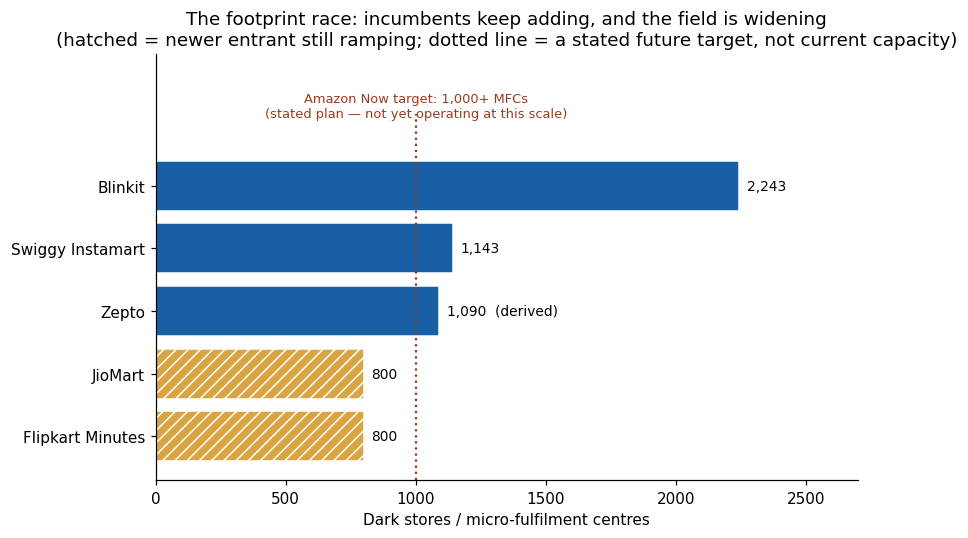

In [7]:
footprint = pd.DataFrame([
    dict(company="Blinkit", stores=2243, status="Established", is_ramping=False),
    dict(company="Swiggy Instamart", stores=1143, status="Established", is_ramping=False),
    dict(company="Zepto", stores=round(zepto_implied_stores), status="Established (derived count)", is_ramping=False),
    dict(company="Flipkart Minutes", stores=800, status="Ramping (+~100/mo)", is_ramping=True),
    dict(company="JioMart", stores=800, status="Ramping (Reliance-backed, CM+ claim)", is_ramping=True),
]).sort_values("stores")

amazon_now_target = combined.loc[
    (combined.company == "Amazon Now") & (combined.metric == "Micro-Fulfilment Centres (count)"), "value"
].iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))
bar_color = ["#D9A441" if r else "#185FA5" for r in footprint["is_ramping"]]
bars = ax.barh(footprint["company"], footprint["stores"],
               color=bar_color,
               hatch=["///" if r else "" for r in footprint["is_ramping"]],
               edgecolor="white")
for y, (val, status) in enumerate(zip(footprint["stores"], footprint["status"])):
    suffix = "  (derived)" if "derived" in status else ""
    ax.text(val + 30, y, f"{val:,.0f}{suffix}", va="center", fontsize=9)

# Amazon Now shown as a separate forward-target marker placed in open space above the
# bars (not at the same height as Blinkit's bar), so it reads as a distinct annotation
# rather than overlapping the chart's data.
ax.set_ylim(-0.7, len(footprint) - 0.5 + 1.6)
ax.axvline(amazon_now_target, color="#993C1D", linestyle=":", linewidth=1.5, ymax=0.86)
ax.text(amazon_now_target, len(footprint) - 0.5 + 0.55,
        f"Amazon Now target: {amazon_now_target:,.0f}+ MFCs\n(stated plan — not yet operating at this scale)",
        color="#993C1D", fontsize=8.5, ha="center", va="bottom")

ax.set_xlabel("Dark stores / micro-fulfilment centres")
ax.set_title("The footprint race: incumbents keep adding, and the field is widening\n(hatched = newer entrant still ramping; dotted line = a stated future target, not current capacity)")
ax.set_xlim(0, 2700)
plt.tight_layout()
plt.savefig(PROCESSED / "b3_chart_dark_store_footprint_race.png", bbox_inches="tight")
plt.show()

**Verdict on H3.3:** Supported. Even setting aside Amazon's not-yet-realized
target, Flipkart Minutes alone is adding stores at a pace (~100/month) that would let it
overtake Zepto's *entire current estimated footprint* in about three months if sustained —
and **JioMart** is scaling in parallel (~1.6M orders/day, +53% QoQ) while *claiming*
contribution-margin positivity on Reliance's grocery-sourcing scale. The fragmentation pressure
is not hypothetical — it is visibly underway in store-count terms, on top of the share eroded
already, and now comes from three deep-pocketed parents (Walmart, Amazon, Reliance) rather than
one more VC-funded challenger.


## H3.4 — Strategic positioning: ticket size vs. frequency

Plotting AOV against density puts all three established players on one map and makes the
trade-off Branch 1 and Branch 2 each found separately visible as a single shape.


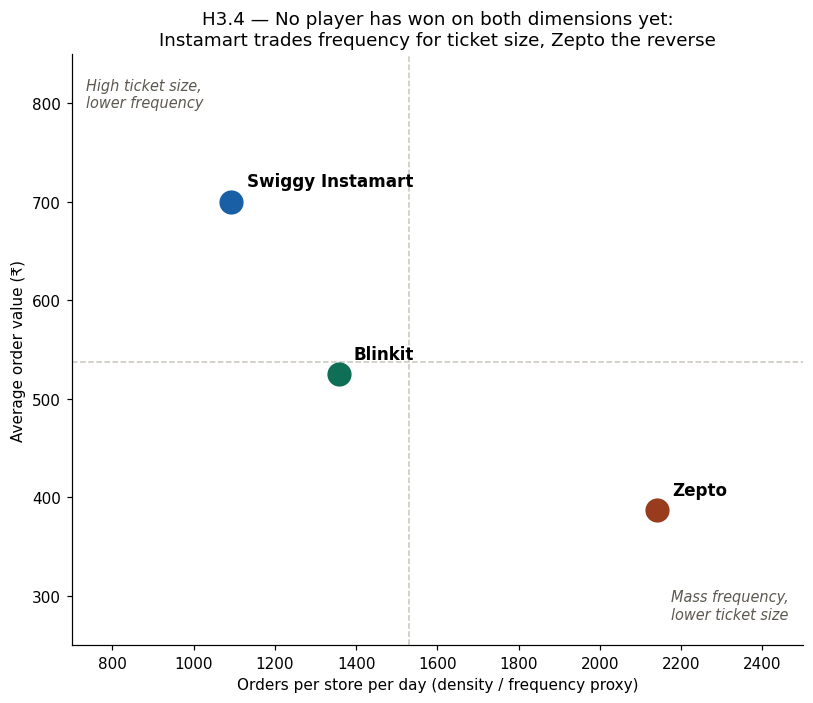

In [8]:

positioning = combined[combined.metric.isin(["AOV", "Orders per Store per Day"])].copy()
positioning = positioning[positioning.company.isin(["Swiggy Instamart", "Blinkit", "Zepto"])]
pivot = positioning.pivot(index="company", columns="metric", values="value").reset_index()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
colors = {"Swiggy Instamart": "#185FA5", "Blinkit": "#0F6E56", "Zepto": "#993C1D"}
for _, row in pivot.iterrows():
    ax.scatter(row["Orders per Store per Day"], row["AOV"], s=220, color=colors[row["company"]], zorder=3)
    ax.annotate(row["company"], (row["Orders per Store per Day"], row["AOV"]),
                textcoords="offset points", xytext=(10, 10), fontsize=11, fontweight="bold")

mid_density = pivot["Orders per Store per Day"].mean()
mid_aov = pivot["AOV"].mean()
ax.axvline(mid_density, color="#C9C5BA", linestyle="--", linewidth=1)
ax.axhline(mid_aov, color="#C9C5BA", linestyle="--", linewidth=1)

ax.text(0.02, 0.96, "High ticket size,\nlower frequency", transform=ax.transAxes, fontsize=9.5,
        color="#5C5850", style="italic", va="top")
ax.text(0.98, 0.04, "Mass frequency,\nlower ticket size", transform=ax.transAxes, fontsize=9.5,
        color="#5C5850", style="italic", va="bottom", ha="right")

ax.set_xlabel("Orders per store per day (density / frequency proxy)")
ax.set_ylabel("Average order value (₹)")
ax.set_title("H3.4 — No player has won on both dimensions yet:\nInstamart trades frequency for ticket size, Zepto the reverse")
ax.set_xlim(700, 2500)
ax.set_ylim(250, 850)
plt.tight_layout()
plt.savefig(PROCESSED / "b3_chart_aov_density_positioning.png", bbox_inches="tight")
plt.show()


**Verdict on H3.4:** Supported as a positioning observation, though "frequency
beats ticket size" is an overstatement of what the data shows. Zepto's higher frequency
hasn't translated into a better per-order loss than Instamart's (Notebook 02's cross-player
regression found this directly: Zepto's per-order loss, ₹78.75, sits close to Instamart's
₹85.18 despite roughly double the density). The more defensible claim: **Blinkit is the
only player combining respectable density with strong unit economics**, and that gap
looks more attributable to its inventory-model structure than to its position on this
density/AOV map alone.


## H3.2 — Metro saturation (qualitative only)

No public data isolates "demand splitting from competitor density" as a distinct effect
from the order-share and density figures already covered above — they would be the same
underlying phenomenon viewed twice. **Verdict: not separately testable** with the data in
this case study; treat H3.2 as covered by the order-share (H3.1) and positioning (H3.4)
findings rather than as an independent data point.


## New-entrant timeline (qualitative reference)

| Entrant | Current state | Stated plan |
|---|---|---|
| Flipkart Minutes | ~800 dark stores (Q1 CY2026), adding ~100/month | ~1,200–1,500 stores by end-2026 |
| Amazon Now | Early-stage rollout (~300 MFCs) | 100 cities, 1,000+ micro-fulfilment centres, ₹2,800cr committed |
| JioMart (Reliance) | ~1.6M orders/day (Q3 FY26, +53% QoQ), ~800 dark stores | CFO claims contribution-margin positive on Reliance grocery-sourcing scale |

All three are framed by their parent companies as strategic priorities backed by deep balance
sheets (Flipkart/Walmart, Amazon, Reliance) — a meaningfully different competitive threat profile
than Zepto's, which is VC-backed and IPO-bound rather than backed by an existing profitable retail
giant. JioMart is the most striking: a fast-scaling entrant *already claiming* contribution-margin
positivity, which — if real — undercuts the assumption that scale-without-profit is the only way to
enter.


## Branch 3 summary

In [9]:
verdict = pd.DataFrame([
    dict(hypothesis_id="H3.1", hypothesis="Instamart losing share of incremental category growth",
         verdict="Strongly supported", evidence="Order share fell 34.3% -> 24.5% -> 20.9%, FY24-FY26 (Zepto UDRHP)"),
    dict(hypothesis_id="H3.2", hypothesis="Metro saturation caps orders/store and AOV via demand-splitting",
         verdict="Not separately testable", evidence="Same underlying phenomenon as H3.1/H3.4 — no independent data"),
    dict(hypothesis_id="H3.3", hypothesis="New entrants (Amazon Now, Flipkart Minutes) fragmenting demand",
         verdict="Supported", evidence="Flipkart Minutes ~800 stores, +~100/month (target 1,200-1,500 by end-2026); Amazon targeting 100 cities, 1,000+ MFCs; JioMart ~1.6M orders/day (+53% QoQ), CM-positive claim"),
    dict(hypothesis_id="H3.4", hypothesis="Zepto's higher throughput despite lower AOV proves frequency beats ticket size",
         verdict="Partially supported / overstated", evidence="Zepto's density lead hasn't produced better unit economics than Instamart's — Blinkit's model, not density, looks decisive"),
])
verdict.to_csv(PROCESSED / "b3_verdict_summary.csv", index=False)
verdict

,hypothesis_id,hypothesis,verdict,evidence
0,H3.1,Instamart losing share of incremental category growth,Strongly supported,"Order share fell 34.3% -> 24.5% -> 20.9%, FY24-FY26 (Zepto UDRHP)"
1,H3.2,Metro saturation caps orders/store and AOV via demand-splitting,Not separately testable,Same underlying phenomenon as H3.1/H3.4 — no independent data
2,H3.3,"New entrants (Amazon Now, Flipkart Minutes) fragmenting demand",Supported,"Flipkart Minutes ~800 stores, +~100/month (target 1,200-1,500 by end-2026); Amazon tar..."
3,H3.4,Zepto's higher throughput despite lower AOV proves frequency beats ticket size,Partially supported / overstated,Zepto's density lead hasn't produced better unit economics than Instamart's — Blinkit'...
